In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import  silhouette_score
from sklearn import datasets
from yellowbrick.cluster import SilhouetteVisualizer
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_excel('Sales_Dataset_2024.xlsx')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2000 non-null   datetime64[ns]
 1   Region       1961 non-null   object        
 2   Product      1960 non-null   object        
 3   Salesperson  1960 non-null   object        
 4   Units_Sold   1960 non-null   float64       
 5   Unit_Price   1960 non-null   float64       
 6   Category     2000 non-null   object        
 7   Revenue      1921 non-null   float64       
 8   Cost         1921 non-null   float64       
 9   Profit       1921 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 156.4+ KB


In [4]:
df

,Date,Region,Product,Salesperson,Units_Sold,Unit_Price,Category,Revenue,Cost,Profit
0,2024-04-12,North,Smartwatch,Hannah,15.0,1224.0,Accessories,18360.0,16451.634258,1908.365742
1,2024-12-14,North,Monitor,Eva,5.0,1321.0,Office,6605.0,4457.351727,2147.648273
2,2024-09-27,North,Mobile,Bob,11.0,912.0,Electronics,10032.0,6563.644126,3468.355874
3,2024-04-16,West,Monitor,Charlie,18.0,325.0,Office,5850.0,4320.807092,1529.192908
4,2024-03-12,West,Headphones,Eva,13.0,1042.0,Accessories,13546.0,8270.122666,5275.877334
...,...,...,...,...,...,...,...,...,...,...
1995,2024-10-10,East,Headphones,David,3.0,1333.0,Accessories,3999.0,3227.051448,771.948552
1996,2024-04-30,North,Tablet,Alice,6.0,703.0,Electronics,4218.0,3249.244924,968.755076
1997,2024-04-16,North,Smartwatch,Grace,7.0,1760.0,Accessories,12320.0,8980.011984,3339.988016
1998,2024-06-23,South,Printer,Charlie,1.0,1114.0,Office,1114.0,941.813213,172.186787


In [5]:
df.describe()

,Date,Units_Sold,Unit_Price,Revenue,Cost,Profit
count,2000,1960.000000,1960.000000,1921.000000,1921.000000,1921.000000
mean,2024-07-01 16:25:40.800000,10.089286,1062.118878,10785.823529,8065.726146,2720.097383
min,2024-01-01 00:00:00,-5.000000,-100.000000,-8975.000000,-7905.695724,-1069.304276
25%,2024-04-04 00:00:00,5.000000,592.500000,3597.000000,2665.613741,784.467841
50%,2024-07-01 00:00:00,10.000000,1073.500000,8268.000000,6014.593046,1928.596208
75%,2024-10-03 00:00:00,15.000000,1519.750000,16461.000000,12152.488896,3936.337721
max,2024-12-31 00:00:00,19.000000,1997.000000,37715.000000,31723.724915,14409.770718
std,NaN,5.601601,545.428034,8722.447605,6645.827102,2502.678468


In [6]:
df = df[df['Profit'] > 0]

In [7]:
df.head()

,Date,Region,Product,Salesperson,Units_Sold,Unit_Price,Category,Revenue,Cost,Profit
0,2024-04-12,North,Smartwatch,Hannah,15.0,1224.0,Accessories,18360.0,16451.634258,1908.365742
1,2024-12-14,North,Monitor,Eva,5.0,1321.0,Office,6605.0,4457.351727,2147.648273
2,2024-09-27,North,Mobile,Bob,11.0,912.0,Electronics,10032.0,6563.644126,3468.355874
3,2024-04-16,West,Monitor,Charlie,18.0,325.0,Office,5850.0,4320.807092,1529.192908
4,2024-03-12,West,Headphones,Eva,13.0,1042.0,Accessories,13546.0,8270.122666,5275.877334


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1911 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1911 non-null   datetime64[ns]
 1   Region       1876 non-null   object        
 2   Product      1874 non-null   object        
 3   Salesperson  1873 non-null   object        
 4   Units_Sold   1911 non-null   float64       
 5   Unit_Price   1911 non-null   float64       
 6   Category     1911 non-null   object        
 7   Revenue      1911 non-null   float64       
 8   Cost         1911 non-null   float64       
 9   Profit       1911 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 164.2+ KB


In [9]:
df['Product'].unique()

array(['Smartwatch', 'Monitor', 'Mobile', 'Headphones', 'Camera',
       'Laptop', 'Printer', 'Tablet', nan, 'SMARTWATCH', 'headPhones',
       'laptop'], dtype=object)

In [10]:
df['Region'].unique()

array(['North', 'West', 'East', 'South', nan, 'south', 'westt', 'Easst',
       'NORTH', 'north'], dtype=object)

In [11]:
df=df.replace('north','North')
df=df.replace('south','South')
df=df.replace('westt','West')
df=df.replace('Easst','East')
df=df.replace('NORTH','North')


In [12]:
df['Region'].unique()

array(['North', 'West', 'East', 'South', nan], dtype=object)

In [13]:
df=df.replace('laptop','Laptop')
df=df.replace('SMARTWATCH','Smartwatch')
df=df.replace('headPhones','Headphones')
df=df.replace('MOBLIE','Mobile')
df=df.replace('tabllet','Tablet')

In [14]:
df1=df[['Product','Unit_Price']].drop_duplicates()

In [15]:
df1 # δεν εχω μοναδικές τιμές προιοντος

,Product,Unit_Price
0,Smartwatch,1224.0
1,Monitor,1321.0
2,Mobile,912.0
3,Monitor,325.0
4,Headphones,1042.0
...,...,...
1994,Headphones,1661.0
1996,Tablet,703.0
1997,Smartwatch,1760.0
1998,Printer,1114.0


In [16]:
df=df.drop(["Date",'Salesperson'], axis=1)

In [17]:
df=df.dropna(subset=['Product'])

In [18]:
df=df.dropna(subset=["Region"])

In [19]:
df_dummies=pd.get_dummies(df)

In [20]:
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1841 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Units_Sold            1841 non-null   float64
 1   Unit_Price            1841 non-null   float64
 2   Revenue               1841 non-null   float64
 3   Cost                  1841 non-null   float64
 4   Profit                1841 non-null   float64
 5   Region_East           1841 non-null   bool   
 6   Region_North          1841 non-null   bool   
 7   Region_South          1841 non-null   bool   
 8   Region_West           1841 non-null   bool   
 9   Product_Camera        1841 non-null   bool   
 10  Product_Headphones    1841 non-null   bool   
 11  Product_Laptop        1841 non-null   bool   
 12  Product_Mobile        1841 non-null   bool   
 13  Product_Monitor       1841 non-null   bool   
 14  Product_Printer       1841 non-null   bool   
 15  Product_Smartwatch    1841

<Axes: >

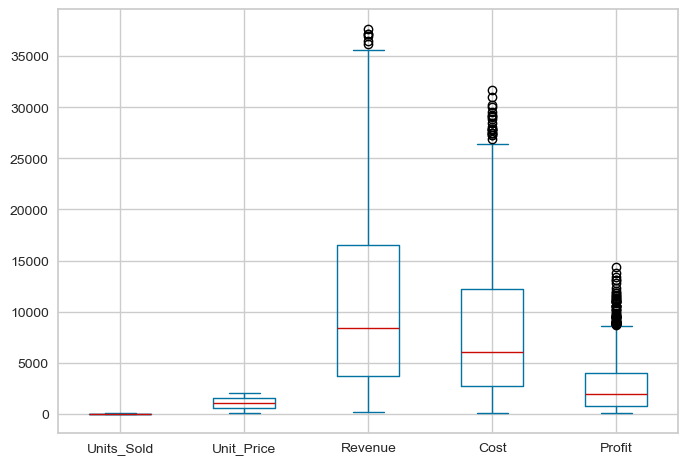

In [21]:
df_dummies.plot(kind='box')

In [22]:
df1=df_dummies
df1

,Units_Sold,Unit_Price,Revenue,Cost,Profit,Region_East,Region_North,Region_South,Region_West,Product_Camera,Product_Headphones,Product_Laptop,Product_Mobile,Product_Monitor,Product_Printer,Product_Smartwatch,Product_Tablet,Category_Accessories,Category_Electronics,Category_Office
0,15.0,1224.0,18360.0,16451.634258,1908.365742,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False
1,5.0,1321.0,6605.0,4457.351727,2147.648273,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True
2,11.0,912.0,10032.0,6563.644126,3468.355874,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False
3,18.0,325.0,5850.0,4320.807092,1529.192908,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True
4,13.0,1042.0,13546.0,8270.122666,5275.877334,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3.0,1333.0,3999.0,3227.051448,771.948552,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False
1996,6.0,703.0,4218.0,3249.244924,968.755076,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False
1997,7.0,1760.0,12320.0,8980.011984,3339.988016,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False
1998,1.0,1114.0,1114.0,941.813213,172.186787,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True


In [23]:
ss = StandardScaler()
ss.fit(df1)
df_scaled = ss.transform(df1)

In [24]:
df_scaled

array([[ 0.86884813,  0.29078428,  0.85793411, ...,  1.73017121,
        -1.02363613, -0.55873801],
       [-0.92316331,  0.47022848, -0.48986684, ..., -0.57797748,
        -1.02363613,  1.78974757],
       [ 0.15204356, -0.28639707, -0.096935  , ..., -0.57797748,
         0.97690964, -0.55873801],
       ...,
       [-0.56476102,  1.28235223,  0.16540176, ...,  1.73017121,
        -1.02363613, -0.55873801],
       [-1.63996789,  0.08729085, -1.11945213, ..., -0.57797748,
        -1.02363613,  1.78974757],
       [-1.63996789,  0.23898595, -1.1100502 , ..., -0.57797748,
         0.97690964, -0.55873801]])

In [25]:
# K-Means

In [26]:
model_kmeans = KMeans(n_clusters=2, random_state=0).fit(df_scaled)

In [27]:
model_kmeans.labels_

array([1, 0, 1, ..., 1, 0, 1])

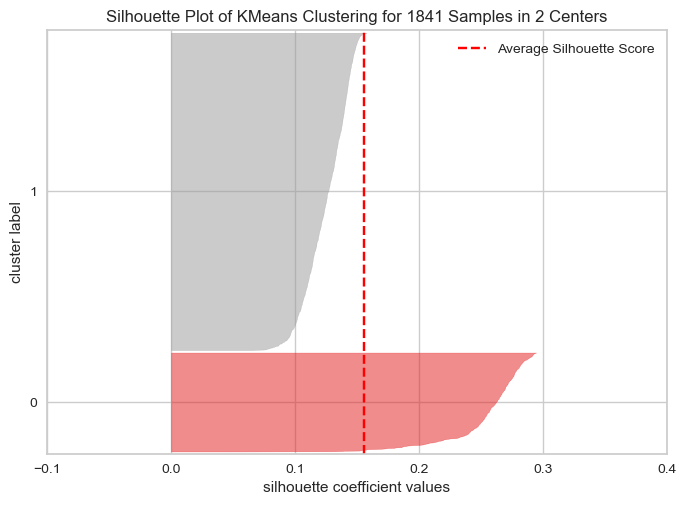

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1841 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [28]:
# Silhouette Score
vizualizer = SilhouetteVisualizer(model_kmeans,color='yellowbrick')
vizualizer.fit(df_scaled)
vizualizer.poof()

In [29]:
X=df_scaled

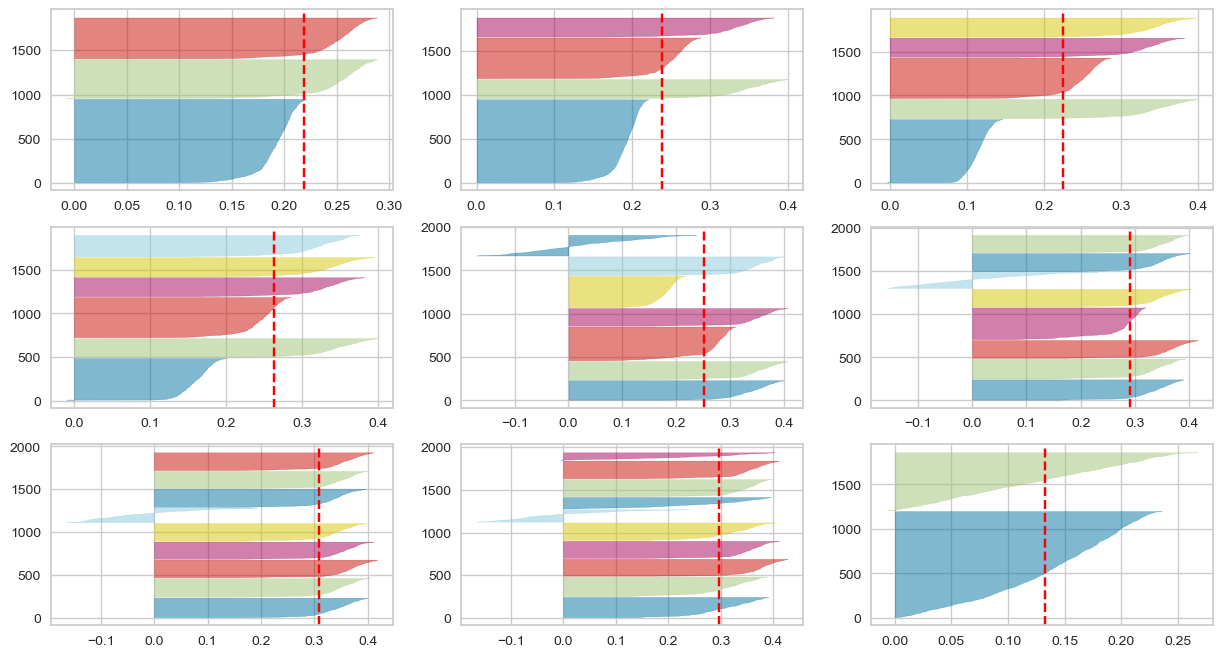

In [30]:
fig, ax = plt.subplots(3,3,figsize=(15,8))


for i in [2,3,4,5,6,7,8,9,10]:

    km = KMeans(n_clusters=i,max_iter=10000,random_state=42)
    q,mod = divmod(i,3)
    visuaziler = SilhouetteVisualizer(km,colors="yellowbrick", ax = ax[q-1][mod])
    visuaziler.fit(X)

In [31]:
# Elbow Method

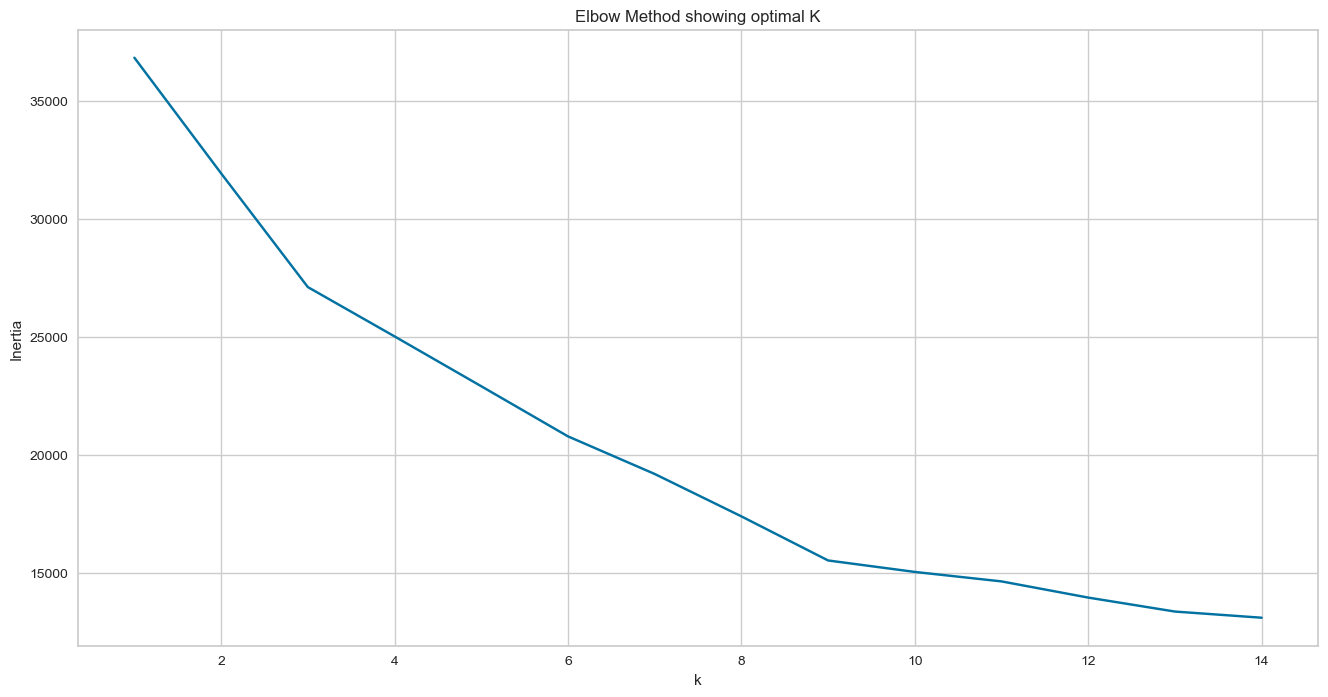

In [70]:
inertia = []

K = range(1,15)

for k in K:

    kmeanModel = KMeans(n_clusters=k,random_state=42)
    kmeanModel.fit(X)
    inertia.append(kmeanModel.inertia_)

plt.figure(figsize=(16,8))
plt.plot(K,inertia,'bx-')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method showing optimal K")
plt.show()

In [33]:
#k-means 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

In [34]:
#PCA για visualization σε 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]

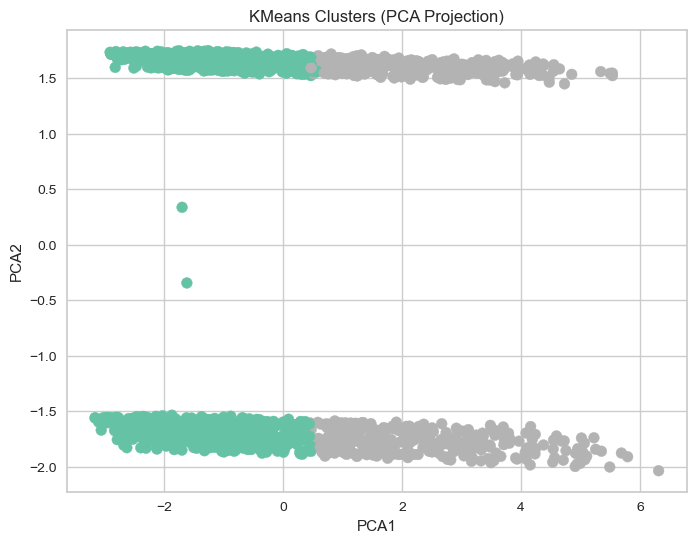

In [35]:
#Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], cmap=plt.cm.Set2, s=60)
plt.title("KMeans Clusters (PCA Projection)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [36]:
pca.explained_variance_ratio_

array([0.18467674, 0.1410747 ])

In [37]:
df

,Region,Product,Units_Sold,Unit_Price,Category,Revenue,Cost,Profit,Cluster,PCA1,PCA2
0,North,Smartwatch,15.0,1224.0,Accessories,18360.0,16451.634258,1908.365742,1,1.468044,-1.794420
1,North,Monitor,5.0,1321.0,Office,6605.0,4457.351727,2147.648273,0,-1.094216,-1.644587
2,North,Mobile,11.0,912.0,Electronics,10032.0,6563.644126,3468.355874,0,-0.145304,1.621528
3,West,Monitor,18.0,325.0,Office,5850.0,4320.807092,1529.192908,0,-0.919699,-1.673632
4,West,Headphones,13.0,1042.0,Accessories,13546.0,8270.122666,5275.877334,1,1.025123,-1.876241
...,...,...,...,...,...,...,...,...,...,...,...
1995,East,Headphones,3.0,1333.0,Accessories,3999.0,3227.051448,771.948552,0,-1.281785,-1.715768
1996,North,Tablet,6.0,703.0,Electronics,4218.0,3249.244924,968.755076,0,-1.523553,1.675345
1997,North,Smartwatch,7.0,1760.0,Accessories,12320.0,8980.011984,3339.988016,1,0.619985,-1.824013
1998,South,Printer,1.0,1114.0,Office,1114.0,941.813213,172.186787,0,-2.491152,-1.576151


In [38]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df1.columns,
    index=['PCA1','PCA2']
)

loadings

,Units_Sold,Unit_Price,Revenue,Cost,Profit,Region_East,Region_North,Region_South,Region_West,Product_Camera,Product_Headphones,Product_Laptop,Product_Mobile,Product_Monitor,Product_Printer,Product_Smartwatch,Product_Tablet,Category_Accessories,Category_Electronics,Category_Office
PCA1,0.372399,0.339948,0.515059,0.499621,0.467773,0.015914,-0.011936,-0.037565,0.033402,0.013587,0.018888,-0.001141,-0.021224,-0.037725,-0.031972,0.028955,0.027639,0.035299,0.013263,-0.051486
PCA2,0.008333,-0.008208,-0.008921,-0.000777,-0.028988,0.018354,-0.001211,0.016146,-0.032555,0.216464,-0.231495,0.226836,0.213144,-0.214509,-0.212527,-0.248003,0.232492,-0.366228,0.594428,-0.325185


In [39]:
loadings.iloc[1].abs().sort_values(ascending=False).head(11)

Category_Electronics    0.594428
Category_Accessories    0.366228
Category_Office         0.325185
Product_Smartwatch      0.248003
Product_Tablet          0.232492
Product_Headphones      0.231495
Product_Laptop          0.226836
Product_Camera          0.216464
Product_Monitor         0.214509
Product_Mobile          0.213144
Product_Printer         0.212527
Name: PCA2, dtype: float64

In [40]:
#k-means 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

In [41]:
#PCA για visualization σε 2D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]
df["PCA3"] = X_pca[:,2]

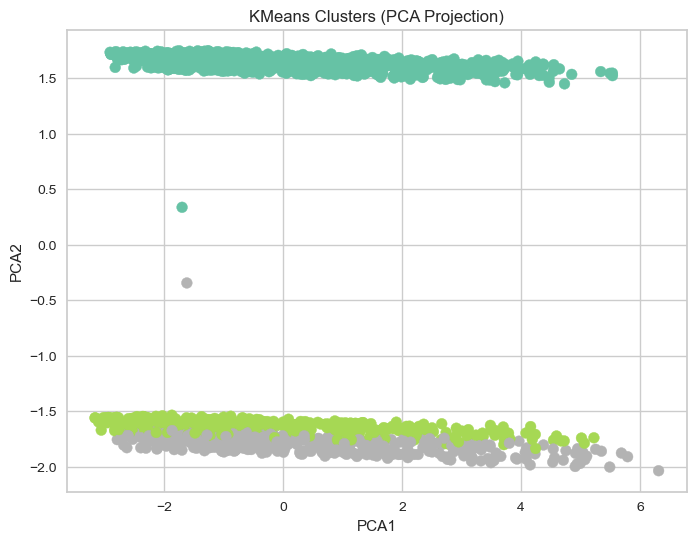

In [42]:
#Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], cmap=plt.cm.Set2, s=60)
plt.title("KMeans Clusters (PCA Projection)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [43]:
#k-means 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

In [44]:
#PCA για visualization σε 2D
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)
df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]
df["PCA3"] = X_pca[:,2]
df["PCA4"] = X_pca[:,3]

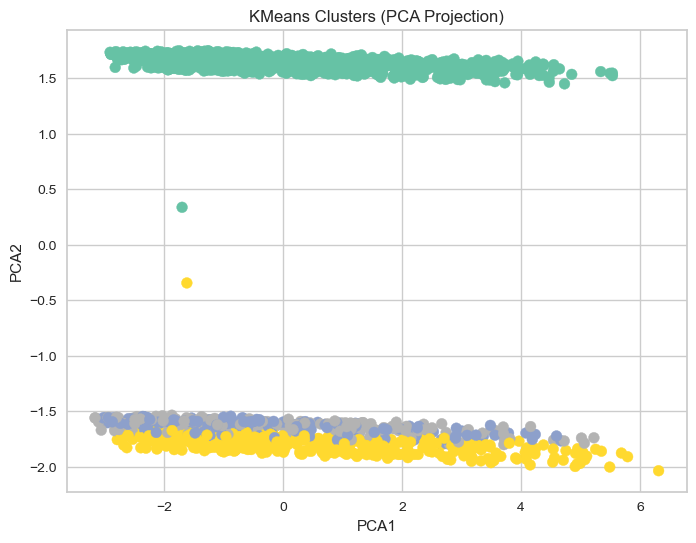

In [45]:
#Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], cmap=plt.cm.Set2, s=60)
plt.title("KMeans Clusters (PCA Projection)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

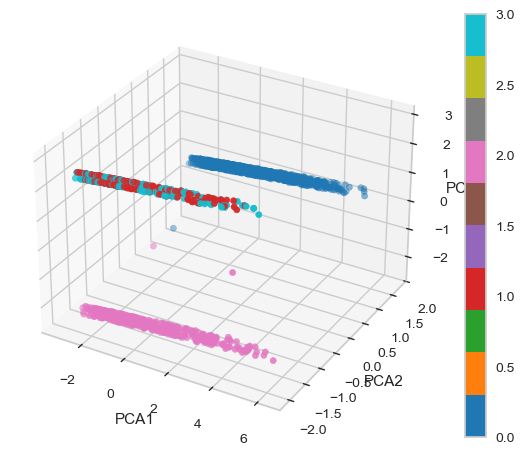

In [46]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    df["PCA1"],
    df["PCA2"],
    df["PCA3"],
    c=df["Cluster"],
    cmap="tab10"
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

plt.colorbar(scatter)
plt.show()

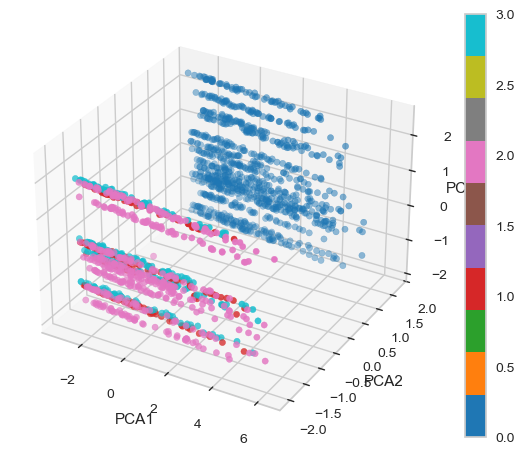

In [47]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    df["PCA1"],
    df["PCA2"],
    df["PCA4"],
    c=df["Cluster"],
    cmap="tab10"
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA4")

plt.colorbar(scatter)
plt.show()

In [48]:
df

,Region,Product,Units_Sold,Unit_Price,Category,Revenue,Cost,Profit,Cluster,PCA1,PCA2,PCA3,PCA4
0,North,Smartwatch,15.0,1224.0,Accessories,18360.0,16451.634258,1908.365742,2,1.468044,-1.794420,-1.927105,0.019042
1,North,Monitor,5.0,1321.0,Office,6605.0,4457.351727,2147.648273,1,-1.094216,-1.644587,2.378835,-0.108703
2,North,Mobile,11.0,912.0,Electronics,10032.0,6563.644126,3468.355874,0,-0.145304,1.621528,0.028730,0.662846
3,West,Monitor,18.0,325.0,Office,5850.0,4320.807092,1529.192908,1,-0.919699,-1.673632,2.214172,1.681040
4,West,Headphones,13.0,1042.0,Accessories,13546.0,8270.122666,5275.877334,2,1.025123,-1.876241,-2.067182,1.335207
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,East,Headphones,3.0,1333.0,Accessories,3999.0,3227.051448,771.948552,2,-1.281785,-1.715768,-2.336104,-0.674219
1996,North,Tablet,6.0,703.0,Electronics,4218.0,3249.244924,968.755076,0,-1.523553,1.675345,-0.075451,-0.422923
1997,North,Smartwatch,7.0,1760.0,Accessories,12320.0,8980.011984,3339.988016,2,0.619985,-1.824013,-1.979053,0.013141
1998,South,Printer,1.0,1114.0,Office,1114.0,941.813213,172.186787,3,-2.491152,-1.576151,2.201495,-1.256851


<Axes: >

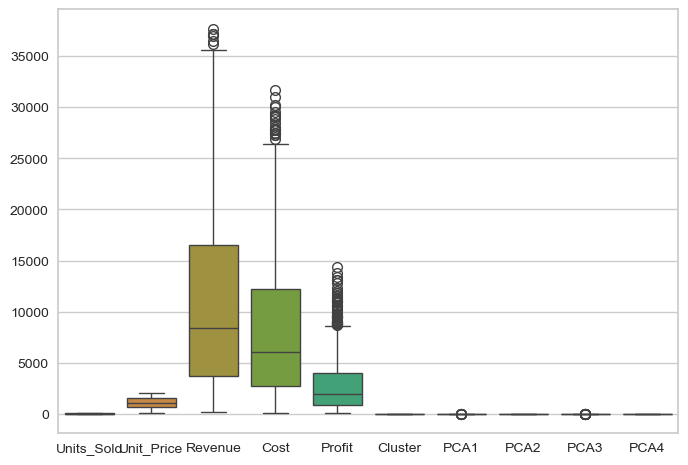

In [49]:
sns.boxplot(df)

In [50]:
pd.crosstab(df["Cluster"], df["Category"])

Category,Accessories,Electronics,Office
Cluster,,,
0,0,942,0
1,0,0,220
2,461,0,1
3,0,0,217


In [51]:
df["Cluster"].value_counts()

Cluster
0    942
2    462
1    220
3    217
Name: count, dtype: int64

In [52]:
df.groupby("Region")[['Units_Sold','Unit_Price','Revenue','Profit','Cost']].sum()

,Units_Sold,Unit_Price,Revenue,Profit,Cost
Region,,,,,
East,4504.0,476879.0,4883122.0,1.219479e+06,3.663643e+06
North,4712.0,496034.0,5023413.0,1.268022e+06,3.755391e+06
South,4460.0,469800.0,4650922.0,1.189670e+06,3.461252e+06
West,5013.0,521292.0,5467891.0,1.373399e+06,4.094492e+06


In [53]:
df.groupby("Cluster")[['Units_Sold','Unit_Price','Revenue','Profit','Cost']].median()

,Units_Sold,Unit_Price,Revenue,Profit,Cost
Cluster,,,,,
0,10.0,1073.5,8814.5,1947.546785,6583.979524
1,9.0,1085.0,7502.5,1868.787793,5599.395846
2,10.0,1075.5,8396.0,2069.109327,6010.654060
3,10.0,1055.0,7030.0,1781.119819,5286.455472


In [54]:
df.groupby("Cluster")[['Units_Sold','Unit_Price','Revenue','Profit','Cost']].mean()

,Units_Sold,Unit_Price,Revenue,Profit,Cost
Cluster,,,,,
0,10.292994,1069.144374,10941.425690,2682.472613,8258.953078
1,9.640909,1071.836364,10212.527273,2635.942954,7576.584319
2,10.264069,1071.051948,11241.127706,2953.115704,8288.012002
3,9.815668,1042.585253,10499.391705,2670.199850,7829.191855


In [55]:
df.groupby(["Region","Cluster"])[['Revenue','Profit']].sum()

Revenue         Profit
Region Cluster                          
East   0        2682600.0  651607.030774
       1         401159.0   98890.369813
       2        1241012.0  327734.574425
       3         558351.0  141246.932471
North  0        2645959.0  645508.071274
       1         621723.0  161842.671888
       2        1132799.0  302885.023721
       3         622932.0  157786.165240
South  0        2363441.0  603895.665739
       1         599828.0  164676.342257
       2        1115939.0  271612.419005
       3         571714.0  149485.102005
West   0        2614823.0  625878.433204
       1         624046.0  154498.065915
       2        1703651.0  462107.437923
       3         525371.0  130915.167751

In [56]:
#percentage of 0 cluster at Revenues
10306823.0/(10306823.0+2246756.0+5193401.0+2278368.0)

0.5146888333725836

In [57]:
df.groupby("Cluster")[['Units_Sold','Unit_Price','Revenue','Profit','Cost']].sum()

,Units_Sold,Unit_Price,Revenue,Profit,Cost
Cluster,,,,,
0,9696.0,1007134.0,10306823.0,2.526889e+06,7.779934e+06
1,2121.0,235804.0,2246756.0,5.799074e+05,1.666849e+06
2,4742.0,494826.0,5193401.0,1.364339e+06,3.829062e+06
3,2130.0,226241.0,2278368.0,5.794334e+05,1.698935e+06


In [58]:
pd.crosstab(df["Cluster"], df["Category"])

Category,Accessories,Electronics,Office
Cluster,,,
0,0,942,0
1,0,0,220
2,461,0,1
3,0,0,217


<Axes: xlabel='Cluster', ylabel='Profit'>

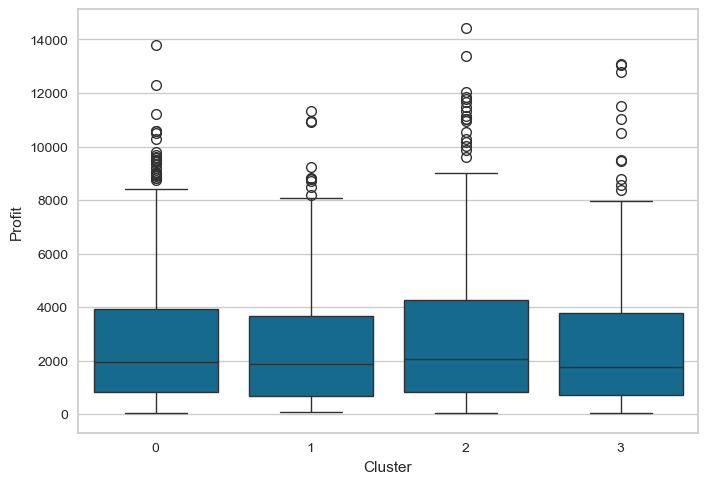

In [59]:
sns.boxplot(x="Cluster", y="Profit", data=df)

<Axes: xlabel='Cluster', ylabel='Revenue'>

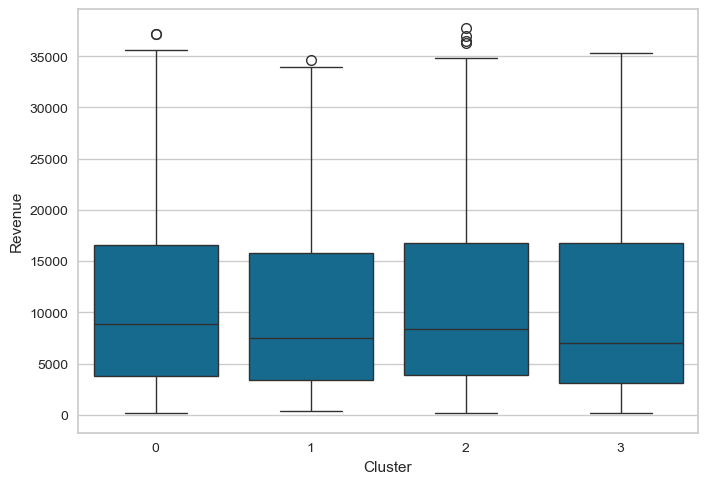

In [60]:
sns.boxplot(x="Cluster", y="Revenue", data=df)

In [61]:
pd.crosstab(df["Cluster"], df["Product"])

Product,Camera,Headphones,Laptop,Mobile,Monitor,Printer,Smartwatch,Tablet
Cluster,,,,,,,,
0,226,1,244,221,0,0,0,250
1,0,0,0,0,220,0,0,0
2,0,220,1,0,0,0,241,0
3,0,0,0,0,0,217,0,0


In [62]:
pd.crosstab(df["Cluster"], df["Region"])

Region,East,North,South,West
Cluster,,,,
0,232,239,238,233
1,43,61,58,58
2,117,109,107,129
3,47,60,53,57
